<a href="https://colab.research.google.com/github/Wai-Fun/Project_ML_MODS-Risk-Assessment/blob/main/MODS_ML_Model_Vitals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Model for Early MODS Risk Assessment Using Clinical Vital Signs

Multiple Organ Dysfunction Syndrome (MODS) is a critical condition characterized by progressive failure of multiple organ systems and is associated with high morbidity and mortality among critically ill patients. The clinical course of MODS can deteriorate rapidly, requiring timely recognition and intervention to prevent further organ injury and improve patient outcomes.

In intensive care settings, continuous or frequent monitoring of physiological parameters is routinely performed because vital signs provide immediate information about changes in patient condition. Compared with laboratory biomarkers or specialized investigations, vital signs are inexpensive, rapidly available, and collected repeatedly throughout hospitalization, making them practical candidates for real-time clinical monitoring.

###Project Objective:

The objective of this project is to develop and evaluate a machine learning model capable of identifying early MODS status using commonly measured vital signs and hemodynamic parameters. The model focuses on six routinely available variables:

- Temperature
- Heart rate
- Respiratory rate
- Systolic blood pressure
- Diastolic blood pressure
- Oxygen saturation

The goal is to determine whether readily accessible bedside measurements can provide clinically meaningful MODS risk estimation and support rapid recognition of patients requiring closer monitoring or intervention.

###Model Development Approach:

Logistic regression and random forest classification models were developed using a structured clinical dataset containing 50,000 patient records. Patients were categorized according to MODS severity, with this analysis focused on distinguishing patients without MODS (Class 0) from those with early MODS (Class 1).

Both models were trained using six routinely collected vital sign and hemodynamic variables, including temperature, heart rate, respiratory rate, systolic blood pressure, diastolic blood pressure, and oxygen saturation. These variables were selected because they represent dynamic physiological changes that occur during acute clinical deterioration and are readily available for continuous bedside monitoring.

A logistic regression model was developed as an interpretable baseline approach. The selected features were standardized and incorporated into a machine learning pipeline with class weighting to address potential imbalance between outcome groups. Logistic regression coefficients were further analyzed to estimate the direction and relative contribution of individual physiological parameters associated with MODS classification.

A random forest classifier was subsequently developed as a comparative machine learning approach capable of capturing nonlinear relationships and interactions among physiological variables. The model was trained using the same feature set and evaluated under identical testing conditions to allow direct performance comparison with logistic regression.

Model comparison was performed to determine the optimal approach for MODS risk assessment. While predictive performance was the primary evaluation criterion, model interpretability and potential clinical implementation considerations were also considered when selecting the final model for individual risk prediction and future deployment.

###Clinical Relevance and Intended Application:

This project emphasizes a practical bedside monitoring approach rather than long-term prediction of MODS occurrence before any physiological deterioration. Although demographic characteristics and pre-existing clinical factors (such as age, sex, BMI, chronic disease history, and surgical history) may be useful for estimating baseline susceptibility, these variables alone did not provide strong predictive performance in this dataset.

In contrast, vital signs reflect dynamic physiological changes occurring during acute illness. Because MODS can develop rapidly in critically ill patients, frequently collected bedside measurements may provide a more actionable signal for identifying patients undergoing clinical deterioration.

The proposed model could serve as a supportive monitoring tool by highlighting patients with increased MODS risk and prompting earlier clinical assessment, closer observation, and timely intervention to reduce progression of organ dysfunction.

###Limitations:

A limitation of this study is that some clinical measurements may have been collected close to or after MODS development, creating the possibility of temporal overlap between predictors and outcome classification. Therefore, the current model should be interpreted as a MODS identification and risk assessment tool rather than a definitive early forecasting model.

###About the Dataset:
The MODS_Clinical_3C_50K dataset is a structured clinical dataset containing 50,000 anonymized patient records and 84 variables, including 83 clinical features and one target variable (mods_stage). Each record represents an individual patient, with features covering demographics, lifestyle factors, medical history, admission characteristics, vital signs, laboratory measurements, inflammatory biomarkers, organ function indicators, cardiovascular and perfusion parameters, respiratory variables, and arterial blood gas measurements.

The target variable, mods_stage, represents three levels of Multiple Organ Dysfunction Syndrome (MODS) severity: Class 0 (No MODS), Class 1 (Early MODS), and Class 2 (Severe MODS). The dataset includes 21,500 Class 0 records, 16,500 Class 1 records, and 12,000 Class 2 records. Selected laboratory variables contain controlled missing values to reflect real-world clinical data availability.

This dataset is suitable for clinical machine learning applications, including classification, predictive modeling, feature analysis, explainable AI, and clinical decision support research.

## 1. Data Loading and Cleaning

In [151]:
# Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix



In [152]:
# Load Data#
df = pd.read_csv("/content/MODS_Clinical_3C_50K-1.csv")

# Verify data was successfully loaded:
df.head(10)

,patient_id,age,sex,weight_kg,height_cm,bmi,smoking_status,alcohol_use,diabetes_history,hypertension_history,...,serum_ferritin,il6,fio2,pao2,pao2_fio2_ratio,pco2,arterial_ph,hco3_abg,base_excess,mods_stage
0,MODS_000001,56,Female,62.6,179.5,19.4,Never,No,0,0,...,246.8,5.5,0.24,108.1,450.4,40.5,7.404,24.7,4.0,0
1,MODS_000002,37,Male,53.8,155.6,22.2,Never,Occasional,0,0,...,242.9,7.3,0.30,107.9,359.7,35.2,7.385,28.2,1.1,0
2,MODS_000003,63,Male,55.7,162.6,21.1,Former,No,1,1,...,206.9,11.7,0.30,86.2,287.3,44.2,7.415,25.8,-0.2,0
3,MODS_000004,65,Male,79.3,161.3,30.5,Former,Frequent,0,0,...,282.8,7.2,0.21,79.1,376.7,36.2,7.367,24.1,-3.7,0
4,MODS_000005,25,Female,68.4,162.0,26.1,Never,Occasional,0,0,...,133.0,1.2,0.21,106.1,500.0,36.3,7.420,23.5,0.3,0
5,MODS_000006,34,Female,57.6,165.6,21.0,Never,Frequent,0,0,...,295.6,9.4,0.25,92.4,369.6,40.1,7.397,27.5,-0.5,0
6,MODS_000007,54,Female,65.9,181.7,20.0,Never,No,0,0,...,253.6,1.0,0.21,114.0,500.0,42.1,7.411,25.0,0.9,0
7,MODS_000008,48,Male,64.6,175.1,21.1,Current,Occasional,0,0,...,173.7,13.5,0.23,105.8,460.0,41.2,7.383,25.1,-2.0,0
8,MODS_000009,52,Male,68.7,178.0,21.7,Never,Occasional,0,0,...,246.8,4.8,0.28,71.4,255.0,44.7,7.386,25.0,-1.1,0
9,MODS_000010,40,Male,46.9,166.3,17.0,Current,No,0,0,...,267.4,2.7,0.21,94.8,451.4,30.9,7.422,23.6,-2.2,0


In [153]:
# Display data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 84 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      50000 non-null  object 
 1   age                             50000 non-null  int64  
 2   sex                             50000 non-null  object 
 3   weight_kg                       50000 non-null  float64
 4   height_cm                       50000 non-null  float64
 5   bmi                             50000 non-null  float64
 6   smoking_status                  50000 non-null  object 
 7   alcohol_use                     50000 non-null  object 
 8   diabetes_history                50000 non-null  int64  
 9   hypertension_history            50000 non-null  int64  
 10  chronic_kidney_disease_history  50000 non-null  int64  
 11  chronic_liver_disease_history   50000 non-null  int64  
 12  chronic_heart_failure_history   

In [154]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [155]:
# Identify int64 columns that are NOT categorical

# Get all int64 columns
int64_cols = df.select_dtypes(include=['int64']).columns

# Print unique values for each int64 column
for col in int64_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


Column: age
Number of unique values: 78
Unique values:
[56 37 63 65 25 34 54 48 52 40 64 53 68 59 57 39 51 49 42 69 50 46 47 58
 82 45 41 61 62 60 43 55 32 73 66 28 36 35 33 38 70 44 74 71 72 31 80 93
 22 67 29 77 75 76 23 87 78 27 81 18 30 20 85 24 19 26 79 88 86 21 95 83
 91 84 90 92 89 94]

Column: diabetes_history
Number of unique values: 2
Unique values:
[0 1]

Column: hypertension_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_kidney_disease_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_liver_disease_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_heart_failure_history
Number of unique values: 2
Unique values:
[0 1]

Column: copd_history
Number of unique values: 2
Unique values:
[0 1]

Column: malignancy_history
Number of unique values: 2
Unique values:
[0 1]

Column: immunosuppression_history
Number of unique values: 2
Unique values:
[0 1]

Column: infection_suspected
Number of unique values: 2
Unique

In [156]:
# Convert int64 columns with continuous data to float64
cols_to_float = ['age', 'heart_rate', 'respiratory_rate',
                 'systolic_bp', 'diastolic_bp']

df[cols_to_float] = df[cols_to_float].astype('float64')

# Verify the changes
print(df[cols_to_float].dtypes)

age                 float64
heart_rate          float64
respiratory_rate    float64
systolic_bp         float64
diastolic_bp        float64
dtype: object


In [157]:
# Check if all column with datatype 'int64' are categorical

# Get all int64 columns
int64_cols = df.select_dtypes(include=['int64']).columns

# Print unique values for each int64 column
for col in int64_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


Column: diabetes_history
Number of unique values: 2
Unique values:
[0 1]

Column: hypertension_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_kidney_disease_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_liver_disease_history
Number of unique values: 2
Unique values:
[0 1]

Column: chronic_heart_failure_history
Number of unique values: 2
Unique values:
[0 1]

Column: copd_history
Number of unique values: 2
Unique values:
[0 1]

Column: malignancy_history
Number of unique values: 2
Unique values:
[0 1]

Column: immunosuppression_history
Number of unique values: 2
Unique values:
[0 1]

Column: infection_suspected
Number of unique values: 2
Unique values:
[0 1]

Column: trauma_history
Number of unique values: 2
Unique values:
[0 1]

Column: sepsis_status
Number of unique values: 2
Unique values:
[0 1]

Column: septic_shock_status
Number of unique values: 2
Unique values:
[0 1]

Column: surgery_within_30_days
Number of unique values: 2
U

In [158]:
# Check for missing values
missing_values = df.isnull().sum()

# Print only column that actually have missing values
columns_with_missing_values = missing_values[missing_values != 0]

print(columns_with_missing_values)


procalcitonin              3000
d_dimer                    2500
troponin                   3000
central_venous_pressure    3500
serum_ferritin             3000
il6                        4000
fio2                       2000
pao2                       2000
dtype: int64


## 2. Exploratory Data Analysis

In [159]:
# Check missing values distributions among mods_stage

# Columns with missing values
cols_with_missing = [
    'procalcitonin',
    'd_dimer',
    'troponin',
    'central_venous_pressure',
    'serum_ferritin',
    'il6',
    'fio2',
    'pao2'
]

# Calculate missing value counts by MODS_stage
missing_by_stage = (
    df.groupby('mods_stage')[cols_with_missing]
      .apply(lambda x: x.isnull().sum())
)

missing_by_stage

,procalcitonin,d_dimer,troponin,central_venous_pressure,serum_ferritin,il6,fio2,pao2
mods_stage,,,,,,,,
0,1330,1035,1270,1527,1261,1720,870,877
1,988,822,1007,1129,1014,1359,679,620
2,682,643,723,844,725,921,451,503


In [160]:
# Statistical information on continuoes data (Expect age)
df.describe(include=['float64'])

,age,weight_kg,height_cm,bmi,capillary_refill_time_sec,temperature_c,heart_rate,respiratory_rate,systolic_bp,diastolic_bp,...,central_venous_pressure,serum_ferritin,il6,fio2,pao2,pao2_fio2_ratio,pco2,arterial_ph,hco3_abg,base_excess
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,...,46500.000000,47000.000000,46000.000000,48000.000000,48000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,58.627940,68.072820,166.959298,24.689426,2.546682,37.574564,98.915060,23.132920,107.655900,67.19236,...,10.452677,483.045030,69.401261,0.381616,82.958837,268.001344,43.307002,7.330799,20.786038,-3.239572
std,14.504096,13.800265,9.021932,5.580687,1.036919,0.917061,23.113889,7.068944,21.140825,14.29105,...,3.784928,401.941677,88.526507,0.175933,18.342119,130.146025,8.143526,0.088032,4.285880,4.325050
min,18.000000,35.000000,140.000000,15.000000,1.000000,34.000000,40.000000,8.000000,60.000000,30.00000,...,0.000000,20.000000,1.000000,0.210000,40.000000,60.000000,20.000000,7.000000,8.000000,-20.000000
25%,49.000000,58.700000,160.900000,20.700000,1.800000,36.900000,82.000000,18.000000,92.000000,57.00000,...,7.700000,180.400000,7.900000,0.240000,70.500000,151.275000,37.800000,7.278000,18.000000,-6.000000
50%,59.000000,68.000000,166.900000,24.400000,2.300000,37.400000,96.000000,22.000000,108.000000,67.00000,...,9.800000,324.500000,25.000000,0.320000,84.500000,260.750000,41.800000,7.354000,21.600000,-2.400000
75%,69.000000,77.400000,173.100000,28.225000,3.200000,38.100000,113.000000,28.000000,123.000000,78.00000,...,12.700000,702.525000,100.000000,0.480000,96.300000,379.600000,47.600000,7.398000,24.000000,0.000000
max,95.000000,138.100000,195.000000,45.000000,6.000000,41.500000,180.000000,45.000000,181.000000,115.00000,...,25.000000,2423.100000,500.000000,1.000000,149.700000,500.000000,87.400000,7.542000,32.400000,9.100000


In [161]:
# Get object columns excluding patient_id
object_cols = df.select_dtypes(include=['object']).columns.drop('patient_id', errors='ignore')

# Print unique values for each object column
for col in object_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


Column: sex
Number of unique values: 2
Unique values:
['Female' 'Male']

Column: smoking_status
Number of unique values: 3
Unique values:
['Never' 'Former' 'Current']

Column: alcohol_use
Number of unique values: 3
Unique values:
['No' 'Occasional' 'Frequent']

Column: admission_type
Number of unique values: 3
Unique values:
['Elective' 'Emergency' 'Urgent']

Column: icu_admission_source
Number of unique values: 4
Unique values:
['ER' 'Ward' 'OT' 'Referral']


## 3. Feature Selection

In [162]:
# =========================
# FEATURE GROUPING
# =========================

All_features = [

    # Demographics & Anthropometrics
    "age",
    "sex",
    "weight_kg",
    "height_cm",
    "bmi",

    # Lifestyle / Behavioral Factors
    "smoking_status",  # 'Never' 'Former' 'Current'
    "alcohol_use", #'No' 'Occasional' 'Frequent'

    # Chronic Disease Risk Factors
    "diabetes_history",
    "hypertension_history",
    "chronic_kidney_disease_history",
    "chronic_liver_disease_history",
    "chronic_heart_failure_history",
    "copd_history",
    "malignancy_history",
    "immunosuppression_history",

    # Admission & Clinical Context
    "admission_type", #'Elective' 'Emergency' 'Urgent'
    "icu_admission_source", # 'ER' 'Ward' 'OT' 'Referral'
    "days_since_symptom_onset",

    # Acute Triggers / Precipitating Events
    "trauma_history",
    "surgery_within_30_days",

    "infection_suspected",
    "sepsis_status",
    "septic_shock_status",

    # Neurologic Assessment
    "initial_gcs",
    "pain_score",

    # Bedside Physiological Assessment
    "capillary_refill_time_sec",

    # Vital Signs & Hemodynamics
    "temperature_c",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "diastolic_bp",
    "mean_arterial_pressure", # MAP is the derivative of SBP and DBP. (multicolinearity issue)
    "oxygen_saturation",
    "shock_index",

    # Fluid Balance & Renal Monitoring
    "urine_output_24h",
    "fluid_balance_24h_ml",
    "urine_output_ml_per_kg_hr",

    # Advanced Organ Support
    "vasopressor_support",
    "mechanical_ventilation",
    "supplemental_oxygen",

    # Hematology
    "hemoglobin",
    "hematocrit",
    "white_blood_cell_count",
    "neutrophil_percent",
    "lymphocyte_percent",
    "platelet_count",
    "red_blood_cell_count",
    "rdw",

    # Inflammation & Infection Biomarkers
    "esr",
    "c_reactive_protein",
    "procalcitonin",
    "d_dimer",
    "serum_ferritin",
    "il6",

    # Renal Function & Electrolytes
    "serum_creatinine",
    "blood_urea_nitrogen",
    "estimated_gfr",
    "sodium",
    "potassium",
    "chloride",
    "bicarbonate",
    "calcium",
    "phosphate",
    "magnesium",

    # Liver Function
    "total_bilirubin",
    "direct_bilirubin",
    "ast",
    "alt",
    "alkaline_phosphatase",
    "albumin",
    "total_protein",
    "inr",

    # Cardiovascular Injury & Perfusion
    "lactate",
    "troponin",
    "central_venous_pressure",

    # Respiratory & Blood Gas Analysis
    "fio2",
    "pao2",
    "pao2_fio2_ratio",
    "pco2",
    "arterial_ph",
    "hco3_abg",
    "base_excess"
]

In [163]:
# Select and define features:

PM2_features = [
    # Vital Signs & Hemodynamics
    "temperature_c",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "diastolic_bp",
    "oxygen_saturation",
    ]

<Figure size 600x400 with 0 Axes>

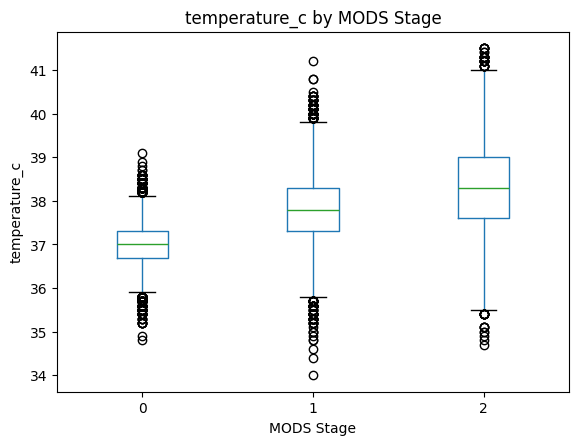

<Figure size 600x400 with 0 Axes>

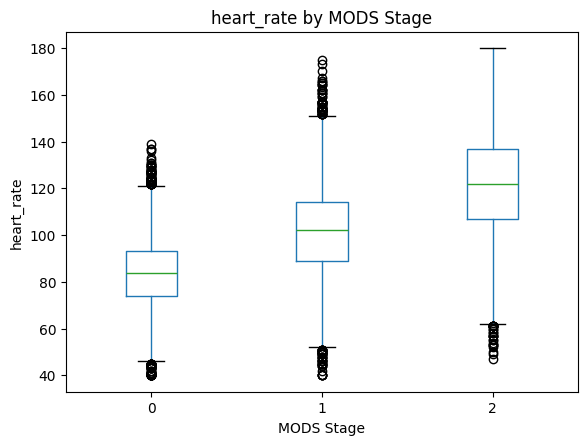

<Figure size 600x400 with 0 Axes>

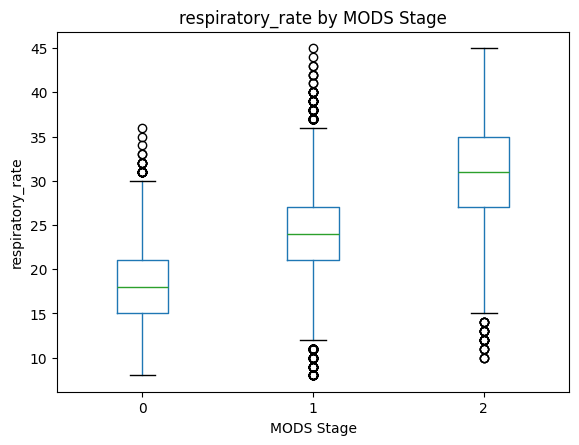

<Figure size 600x400 with 0 Axes>

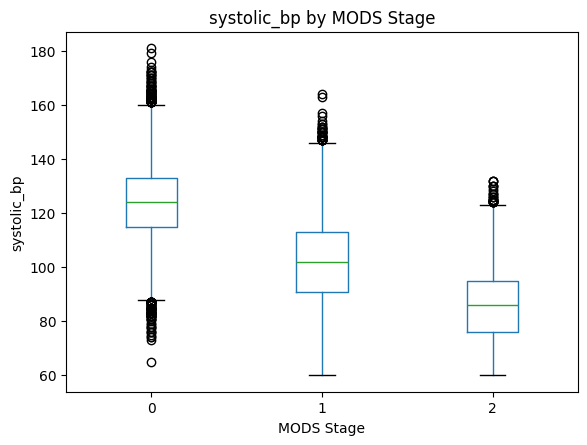

<Figure size 600x400 with 0 Axes>

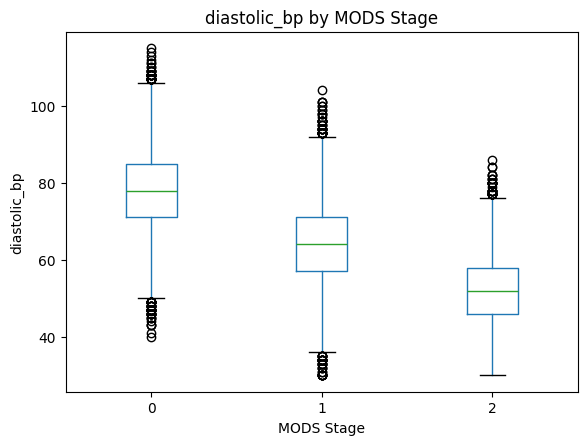

<Figure size 600x400 with 0 Axes>

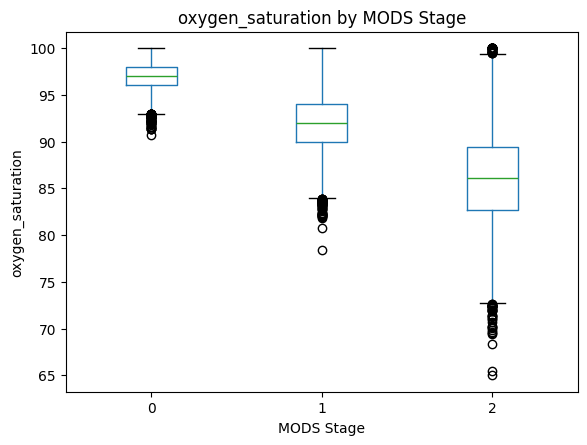

In [164]:
# Create a boxplot for PM2_feature
for feature in PM2_features:
    plt.figure(figsize=(6, 4))

    df.boxplot(
        column=feature,
        by="mods_stage",
        grid=False
    )

    plt.title(f"{feature} by MODS Stage")
    plt.suptitle("")  # remove automatic pandas title
    plt.xlabel("MODS Stage")
    plt.ylabel(feature)

    plt.show()

## 4. Logistric Regression Model Development

In [165]:
# Numeric features
numeric_features = [
    # Vital Signs & Hemodynamics
    "temperature_c",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "diastolic_bp",
    "oxygen_saturation",
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


# Preprocessing pipeline for Logistic Regression
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        )
    ]
)

In [166]:
# Step 1: Create binary MODS dataset (Stage 0 vs Stage 1)

# Keep only No MODS and Early MODS
df_model = df[df["mods_stage"].isin([0, 1])].copy()

# Check distribution
df_model["mods_stage"].value_counts()

,count
mods_stage,
0,21500
1,16500


In [167]:
# Step 2 Define X and Y

X = df_model[PM2_features]
y = df_model["mods_stage"]

In [168]:
# Step 3: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [169]:
# Baseline logistic regression

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=88))])

# Train a Model
model = clf.fit(X_train, y_train)
print('Model trained.')

Model trained.


AUC: 0.994


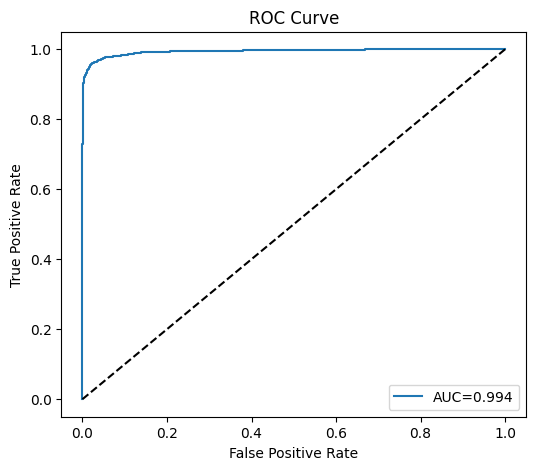

Confusion matrix (0.5 threshold):
 [[4182  118]
 [ 128 3172]]

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      4300
           1       0.96      0.96      0.96      3300

    accuracy                           0.97      7600
   macro avg       0.97      0.97      0.97      7600
weighted avg       0.97      0.97      0.97      7600



In [170]:
# Model testing and validation

# Predictions and probabilities
y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

# ROC and AUC
auc = roc_auc_score(y_test, y_prob)
print('AUC:', round(auc,3))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Confusion matrix at 0.5 threshold
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix (0.5 threshold):\n', cm)
print('\nClassification report:\n', classification_report(y_test, y_pred))

### Note:
Confusion matirx shows that at a probability threshold of 0.5, the model correctly classified 4,182 patients without MODS and 3,172 patients with MODS. Only 118 non-MODS patients were incorrectly flagged as MODS, while 128 MODS patients were missed. These results demonstrate strong classification performance with both high sensitivity and high specificity


AUC = 0.994 indicating outstanding discrimination between MODS and non-MODS patients. This suggests that the model can effectively separate patients with MODS from those without MODS based on routinely measured vital signs.

Recall =0.96.The model correctly identifies approximately 96% of patients with MODS and misses only about 4%. High sensitivity is clinically desirable because failure to recognize MODS may delay intervention and increase the risk of organ deterioration.

Precision = 0.97. When the model predicts MODS, it is correct about 96% of the time.This indicates a low false-positive rate and suggests that most patients flagged by the model truly had MODS.

F1-score =0.96. The F1-score combines precision and recall into a single performance measure. A score of 0.96 indicates an excellent balance between detecting MODS cases and minimizing incorrect alerts, resulting in highly reliable overall classification performance.


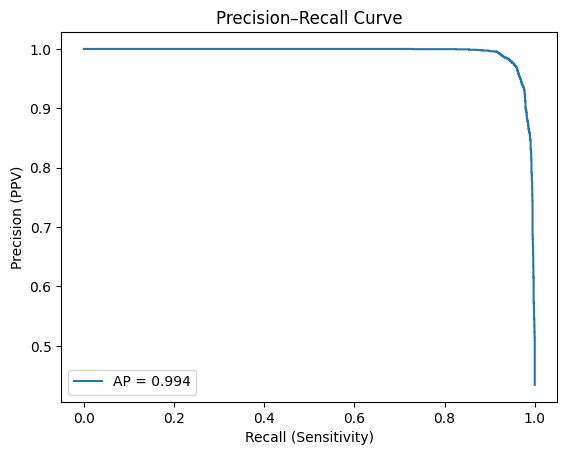

In [171]:
# Precision-Recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

### Precision-Recall curve
The model consistently assigns higher risk scores to MODS patients than to non-MODS patients, allowing accurate identification of MODS cases while maintaining a very low false-positive rate.

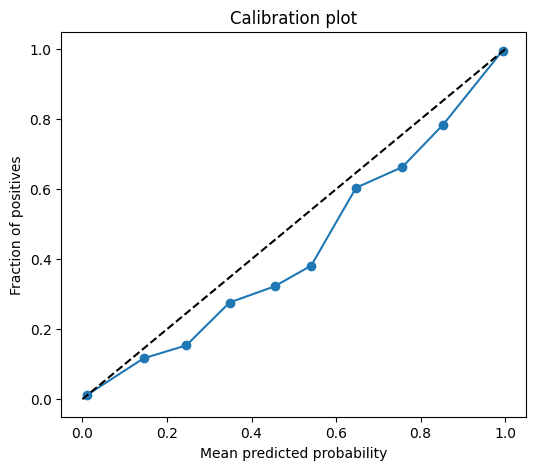

Threshold 0.2: PPV=0.914, Sensitivity=0.978
Threshold 0.3: PPV=0.937, Sensitivity=0.974
Threshold 0.4: PPV=0.952, Sensitivity=0.967
Threshold 0.5: PPV=0.964, Sensitivity=0.961


In [172]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot')
plt.show()

# Explore different thresholds
thresholds = [0.2, 0.3, 0.4, 0.5]
for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    ppv = tp/(tp+fp) if (tp+fp)>0 else 0
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    print(f'Threshold {t}: PPV={ppv:.3f}, Sensitivity={sens:.3f}')

### Calibration Curve

The model is very reliable for identifying which patients are at higher risk than others. However, the predicted probabilities should be interpreted with some caution because the model tends to slightly overestimate MODS risk (The curve lies below the diagaonal) in the moderate and high-risk ranges.

In [173]:
# Cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("5-fold CV AUC:")
print(cv_auc)

print("Mean AUC:", cv_auc.mean())

5-fold CV AUC:
[0.99450009 0.99454017 0.99511187 0.99547051 0.99493569]
Mean AUC: 0.9949116675475688


### 5-fold Cross-validation

The model achieved a mean cross-validated AUC of 0.995 indicating excellent discrimination between patients with and without MODS across multiple validation folds.

The consistency of the AUROC values across all five folds suggests that the model is robust and maintains stable performance when evaluated on different subsets of the dataset. This finding supports the reliability of the selected vital sign variables for identifying patients with MODS.

In [174]:
# Get fitted scaler
scaler = model.named_steps['preprocessor'] \
              .named_transformers_['num'] \
              .named_steps['scaler']

# Standard deviations used by StandardScaler
sd_values = scaler.scale_

# Logistic regression coefficients
coefs = model.named_steps['clf'].coef_[0]

# Create coefficient dataframe
coef_df = pd.DataFrame({
    'feature': numeric_features,
    'coef': coefs,
    'one_SD': sd_values
})

# Correct odds ratio:
# OR > 1: higher feature value associated with increased MODS odds
# OR < 1: higher feature value associated with decreased MODS odds
coef_df['odds_ratio'] = np.exp(coef_df['coef'])

# Effect magnitude (for ranking feature importance only)
coef_df['abs_coef'] = np.abs(coef_df['coef'])

# Direction of association
coef_df['direction'] = np.where(
    coef_df['coef'] > 0,
    'Higher value associated with increased MODS odds',
    'Higher value associated with decreased MODS odds'
)

# Optional: Convert OR into percentage change interpretation
coef_df['odds_change_percent'] = (
    (coef_df['odds_ratio'] - 1) * 100
)

# Sort by absolute effect size
coef_df = (
    coef_df
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)

# Final table
coef_df[
    [
        'feature',
        'coef',
        'one_SD',
        'odds_ratio',
        'odds_change_percent',
        'direction'
    ]
]

,feature,coef,one_SD,odds_ratio,odds_change_percent,direction
0,oxygen_saturation,-3.321677,3.343494,0.036092,-96.390773,Higher value associated with decreased MODS odds
1,systolic_bp,-1.825236,18.292693,0.161180,-83.882044,Higher value associated with decreased MODS odds
2,diastolic_bp,-1.679520,12.189846,0.186464,-81.353648,Higher value associated with decreased MODS odds
3,respiratory_rate,1.566625,5.366055,4.790455,379.045535,Higher value associated with increased MODS odds
4,temperature_c,1.476797,0.759811,4.378897,337.889691,Higher value associated with increased MODS odds
5,heart_rate,1.314344,18.238008,3.722309,272.230871,Higher value associated with increased MODS odds


## 5. Random Forest Model Development and Comparison

A Random Forest classifier was developed to compare performance against the baseline logistic regression model. Unlike logistic regression, which assumes a linear relationship between predictors and MODS probability, Random Forest can capture nonlinear interactions among physiological variables. Both models were trained using the same six vital sign features and evaluated using identical test data.

In [175]:
# Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


In [176]:
# Evaluate Random Forest Model

# Predictions

rf_prob = rf_model.predict_proba(X_test)[:,1]
rf_pred = rf_model.predict(X_test)


# AUC

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest AUC:", round(rf_auc,3))


# Classification report

print(
    classification_report(
        y_test,
        rf_pred
    )
)


# Confusion matrix

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print(cm_rf)

Random Forest AUC: 0.995
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4300
           1       0.97      0.96      0.97      3300

    accuracy                           0.97      7600
   macro avg       0.97      0.97      0.97      7600
weighted avg       0.97      0.97      0.97      7600

[[4199  101]
 [ 116 3184]]


In [177]:
# Feature Importance:

feature_importance = pd.DataFrame({

    "feature": PM2_features,

    "importance": rf_model.feature_importances_

})


feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)


feature_importance

,feature,importance
5,oxygen_saturation,0.434040
3,systolic_bp,0.168327
0,temperature_c,0.125154
4,diastolic_bp,0.111712
2,respiratory_rate,0.100687
1,heart_rate,0.060081


In [178]:
# Compare the Models: Logistic Regression Vs Random Forest
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "AUC": [
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob)
    ],

    "Precision": [
        classification_report(y_test,y_pred,
                             output_dict=True)["1"]["precision"],
        classification_report(y_test,rf_pred,
                             output_dict=True)["1"]["precision"]
    ],

    "Recall": [
        classification_report(y_test,y_pred,
                             output_dict=True)["1"]["recall"],
        classification_report(y_test,rf_pred,
                             output_dict=True)["1"]["recall"]
    ],

    "F1-score": [
        classification_report(y_test,y_pred,
                             output_dict=True)["1"]["f1-score"],
        classification_report(y_test,rf_pred,
                             output_dict=True)["1"]["f1-score"]
    ]

})


comparison

,Model,AUC,Precision,Recall,F1-score
0,Logistic Regression,0.993838,0.964134,0.961212,0.962671
1,Random Forest,0.994927,0.969254,0.964848,0.967046


### Model Comparision: Logistric Regression Vs Random Forest:

Random Forest slightly outperformed Logistic Regression across all evaluated metrics, but the difference is small. Both models demonstrate excellent performance for distinguishing early MODS (Class 1) from no MODS (Class 0).

AUC: The Random Forest model achieved a slightly higher AUC (0.9949) compared with Logistic Regression (0.9938).The small improvement indicates that Random Forest may capture subtle nonlinear relationships and interactions between vital signs that are not fully represented by the linear logistic regression model.

Precision: The higher precision of Random Forest indicates that it produces slightly fewer false-positive MODS alerts.

Recall: Random Forest also achieved slightly higher recall indicating Random Forest missed fewer MODS patients.

Despite the improved predictive performance of Random Forest, the difference between models was relatively small, with both approaches demonstrating excellent discrimination and classification ability. Therefore, model selection should also consider clinical implementation requirements, including interpretability, transparency, and ease of integration into clinical decision-support systems.

### Model Selection:
Although Random Forest achieved slightly higher discrimination, logistic regression may be preferred for clinical deployment because the performance difference was minimal and interpretability is critical in healthcare settings.

###6. Application of the Final Model for Individual Risk Prediction

In [179]:
# Select one patient
patient_id = "MODS_041111"

patient = df[df["patient_id"] == patient_id]

# Select required features
X_patient = patient[PM2_features]

# Predict probability of MODS using Logistic Regression model
mods_probability = model.predict_proba(X_patient)[0, 1]

# Convert probability to percentage
mods_risk = mods_probability * 100

print(f"Predicted MODS risk for {patient_id}: {mods_risk:.1f}%")

Predicted MODS risk for MODS_041111: 100.0%


In [180]:
# Risk Explanation
# Get logistic regression coefficients
coef = model.named_steps['clf'].coef_[0]

# Transform patient features using the same preprocessing pipeline
X_transformed = model.named_steps['preprocessor'].transform(X_patient)

# Calculate contribution of each feature
contributions = X_transformed[0] * coef

explanation = pd.DataFrame({
    "feature": model.named_steps['preprocessor'].get_feature_names_out(),
    "contribution": contributions
})

# Rank features by contribution
explanation = explanation.sort_values(
    "contribution",
    ascending=False
)

In [181]:
print(f"""
Patient: {patient_id}

Predicted MODS probability: {mods_risk:.1f}%

Top risk contributors:
{explanation.head(6)}

""")


Patient: MODS_041111

Predicted MODS probability: 100.0%

Top risk contributors:
                  feature  contribution
5  num__oxygen_saturation      6.972314
1         num__heart_rate      3.194543
4       num__diastolic_bp      1.513167
2   num__respiratory_rate      0.977345
0      num__temperature_c      0.884317
3        num__systolic_bp      0.450176




###6. Futre Deployment Consideration

6.1 EHR Integration

The MODS prediction model could be integrated into an electronic health record (EHR) system to automatically extract relevant clinical variables and generate real-time MODS risk estimates. Future implementation would require standardized data input, automated risk calculation, and continuous monitoring of model performance.

6.2 Clinical Decision Support System (CDSS)

The model could support early MODS risk stratification. The prediction should complement, rather than replace, clinical judgment.

A potential CDSS workflow:

- Patient clinical data are collected during routine care.
- The model estimates the probability of MODS development.
- Patients identified as high risk receive an alert or recommendation for further evaluation.
- Clinicians review the prediction together with other clinical information and determine appropriate management.

Key considerations for clinical implementation include:

- Selection of clinically meaningful risk thresholds.
- Minimization of false-positive alerts and alert fatigue.
- Maintenance of model interpretability.
- Continuous evaluation of model accuracy and calibration.

6.3 Future Validation and Maintenance

Before clinical deployment, the model requires external validation and prospective evaluation in real-world settings. Ongoing monitoring, recalibration, and performance assessment will be necessary to ensure reliability as patient populations and clinical practices evolve.